## Day3 - Bias-Variance & Diagnosing Model Fit
In this notebook we will focuse on learning how to diagnose model and tell whether a model is :
- Underfitting
- Overfitting
- Generalizing
We will also cover the Bais-Variance trade-off and how we can use regularization to decrease overfitting.

## Topics
- Underfitting versus overfitting
- Bias Variance trade-off
- The gap between training and validation score
- Creating an overfitting model
- Creating an underfitting model
- Reducing complexity of a model
- Ridge regression (L2 regularization)
- Lasso regression (L1 regularization)
- Model Comparison
- Model visualization

## Underfitting and Overfitting
Machine learning models can go wrong in many ways but generally they are either underfit or overfit.
### Underfitting – High Bias
Underfitting occurs if the model is not complex enough to learn from the underlying patterns of the data.
Common signs:
- Poor training performance
- Poor validation performance
- Small gap between training and validation performance
Potential fixes:
- More complex model
- Feature addition
- Regularization reduction
- Complexity increase
### Overfitting – High Variance
Overfitting occurs if the model is too complex and learns the training data too well.
Common signs:
- Excellent training performance
- Low validation performance
- Big gap between training and validation performance
Potential fixes:
- Simplify model
- Regularization increase
- Training data addition
- Feature elimination

##  Bias-Variance Trade-off
Bias and variance are two distinct problems.
- High Bias --> Simple Model --> Under-fitting
- High Variance --> Complex Model --> Over-fitting
As the complexity of the model grows:
- Bias decreases.
- Variance increases.
The objective is to achieve a point where the model is complex enough to identify the real pattern but not complex enough to memorize the training data.

## Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

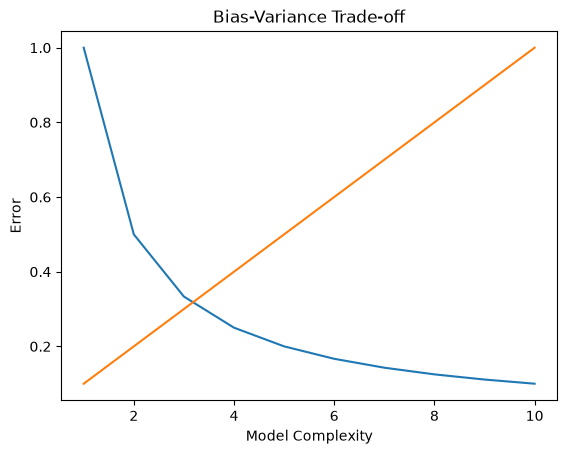

In [42]:
complexity = np.arange(1, 11)
bias = 1 / complexity
variance = complexity / 10
plt.plot(complexity, bias)
plt.plot(complexity, variance)
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-off")
plt.show()

## Analysis of Plot
This Plot shows the general correlation between model complexity, bias, and variance.
An overly simplistic model would have high bias.
An overly complex model would have high variance.
The objective is to find a balance between these two extremes.

## Loading the Dataset
In this training , we will keep on using the Student Performance dataset,the target variable needs to be the final score of the students.
We need to exclude variables which are directly connected to the target variable.
This means that if we use final_exam_score or final_grade as the target variable, we cannot use the other final result column as an input variable Data leakage.

In [6]:
df=pd.read_csv("student_performance_dataset.csv")
df.head(10)

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


In [7]:
print("dataset shape is:",df.shape)

dataset shape is: (1000, 12)


Output display the number of rows and columns in the dataset ,observation count is very important since the amount of data impacts the abillity of the model to generalize.

## Select Features and Target
x --> contains the predictor variables.
y --> contatins the target variable.

In [9]:
x=df.drop(columns=["final_grade","final_exam_score"])
y=df["final_exam_score"]

## Identify Numerical and Categorical Features
Machine Learning requires numerical inputs ,so we should seprate the columns into 
- Numerical columns
- Categorical columns
Categorical will be convertied into numerical values using (**One-Hot-Encoding**)

In [18]:
num_col=x.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_col=x.select_dtypes(include=["object","category","bool"]).columns.tolist()

C:\Users\Ayman\AppData\Local\Temp\ipykernel_3476\2653585438.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=x.select_dtypes(include=["object","category","bool"]).columns.tolist()


## Preprocessing
Categorical features are converted into numerical values using one-hot encoding before training the model.

In [19]:
x = pd.get_dummies(x, columns=cat_col, drop_first=True)

# Train/Validation Split
We need to have training and validation datasets separately,the training dataset is used to fit the model ,the validation dataset is used for evalution of the model and it is not going to be used during training.

In [20]:
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training set:",x_train.shape)
print("validation set:",x_val.shape)

Training set: (800, 12)
validation set: (200, 12)


## Why do we need both scores?
The training score gives us information about how well our model learns the training data,the validation score gives us information about how well our model generalize on the unseen data.
It is one of the most effective way to diagnose model performance.

## Function for Measuring Goodness of Fit of Models
In order to simplify our experments we will implement a function that measures the following parameters:
- Training score
- Validation score
- Train-Validation gap
for regression we will use R^2 ,the higher R^2 means better prediction quality.

In [27]:
def evaluation(model):
    model.fit(x_train,y_train)
    train_predict=model.predict(x_train)
    val_predict=model.predict(x_val)
    train_score=r2_score(y_train,train_predict)
    val_score=r2_score(y_val,val_predict)
    gap=train_score-val_score
    print(f"Training R^2:",{train_score})
    print(f"Validation R^2:",{val_score})
    print(f"Gap R^2:",{gap})
    return train_score,val_score,gap

## How to read the Difference
The general structure to be followed would be as follow
Training Score|Validation Score|Diagnosis
Low            Low              Underfitting
High           Much Lower       Overfitting
High           High             Good-fit
The specific threshold may vary.
It is very important to note the exact value of each score along with the magnitude of the difference.

## Deliberately Overfit the model
We shall try to fit an overly complicated model,Decision Trees which are not constrained by depth can keep splitting the data untile highly specific rules are obtained for individual instances.
The aim is not to develop the best model,the objective is to purposefully construct a poor model so that we know how it looks like.

In [28]:
overfit=DecisionTreeRegressor(max_depth=None,random_state=42)
overfit_train,overfit_val,overfit_gap=evaluation(overfit)

Training R^2: {1.0}
Validation R^2: {0.2528142593290642}
Gap R^2: {0.7471857406709358}


The Large difference between the training and validation scores means that the model behaves better for training data than for validation data it is the case of high variance this shows the overfitting problem.

## Create an Underfit Model on Purpose
we will make a really simple Decision Tree now with the limitation that the maximum depth is 1 ,the model is not able to learn complex relationship at all.
This should show underfitting.

In [29]:
underfit=DecisionTreeRegressor(max_depth=1,random_state=42)
underfit_train,underfit_val,underfit_gap=evaluation(underfit)

Training R^2: {0.2333064132529341}
Validation R^2: {0.1528491435186743}
Gap R^2: {0.08045726973425982}


When the training score and validation score are low then the model is underfit because the it is not complex enogh to learn the patterns of the dataset.
This means there is high bias in the model.

## Fix the overfitting
one of the ways to decrease overfitting is through decreasing  the complexity of our model in the unrestricted tree there was no maximum depth allowed ,now we will restrict depth of the tree.

In [30]:
fixed_model=DecisionTreeRegressor(max_depth=5,random_state=42)
fixed_train,fixed_val,fixed_gap=evaluation(fixed_model)

Training R^2: {0.6194910200036603}
Validation R^2: {0.45518545010977973}
Gap R^2: {0.16430556989388057}


In [34]:
comparison=pd.DataFrame({"Model":["underfit","overfit","after fix"],"Training R^2":[underfit_train,overfit_train,fixed_train],"Validation R^2":[underfit_val,overfit_val,fixed_val],"Gap":[underfit_gap,overfit_gap,fixed_gap]})
comparison

,Model,Training R^2,Validation R^2,Gap
0,underfit,0.233306,0.152849,0.080457
1,overfit,1.000000,0.252814,0.747186
2,after fix,0.619491,0.455185,0.164306


### Analysis of Model Fitness
From the unrestricted decision tree, it is quite obvious that there is an over-fitting problem, since training R^2 is very high, but validation R^2 is very low.
Depth-1 decision tree shows under-fitting, where both training and validation R² are very low.
By constraining the decision tree at depth 5, the gap between train and validation is minimized from about 0.747 to 0.164.

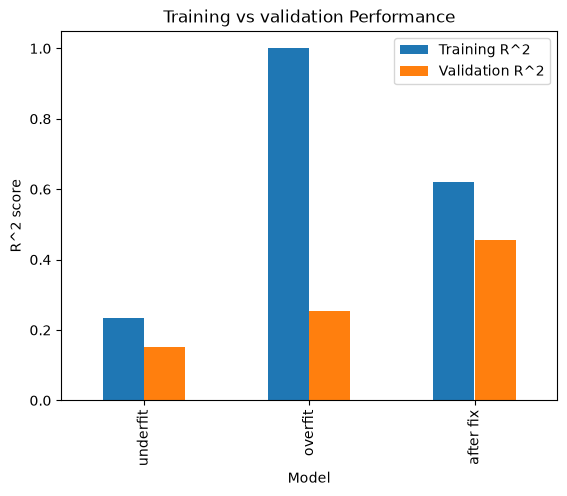

In [35]:
comparison.set_index("Model")[["Training R^2", "Validation R^2"]].plot(kind="bar")
plt.ylabel("R^2 score")
plt.title("Training vs validation Performance")
plt.show()

## Analysis of the Plot
- Underfit: Training and validation performance are both low, suggesting that the model is too simple for capturing patterns from data.
- Overfit: High training score compared to low validation performance shows that the model did not learn but just memorized the training dataset.
- After Fix: The difference between training and validation performance disappears and the performance becomes balanced.

## Compare the overfitted model to the fixed model.
### Before Fix
Training R² = 1.000000
Validation R² = 0.252814
Difference = 0.747186
### After Fix
Training R² = 0.619491
Validation R² = 0.455185
Difference = 0.164306
### Conclusion
Decreasing model complexity will lower overfitting if it reduces the difference between the training and validation sets.
We do not need the highest training score possible.
The target is the good performance on the validation set.

## Regularization
One method employed in addressing the issue of overfitting is that of regularization.
It works by punishing large coefficients and creating a simpler model.
### Ridge – L2
Ridge regression results in small coefficients.
### Lasso – L1
Lasso shrinks some coefficients to zero; it performs feature selection.
The role of the alpha parameter is that:
- Larger alpha → More regularization
- Smaller alpha → Less regularization

Features Standardization
Ridge and Lasso models are sensitive to the scale of features since they penalize the coefficients of the model.
In case the features have different scales, the regularization will impact the coefficients differently,Thus StandardScaler is used for scaling the features prior to using Ridge and Lasso models.
It is trained only on the training dataset and then applied to both the training and validation datasets.
For this purpose, we apply:
- fit_transform() on the training dataset,
- transform() on the validation dataset.
It is not necessary to train the scaler on the validation dataset because it is considered unseen data.

In [38]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_val_scaled=scaler.transform(x_val)

## Ridge Regression – L2 Regularization
This is a linear regression model which applies the L2 regularization method.
The penalty will be applied to the larger coefficients within the model. The larger coefficients will be reduced, therefore.
Alpha is a regularization strength parameter.
In this example, we have used:
alpha = 1.0
The higher value of alpha is indicative of the larger strength of the regularization, whereas the lower value corresponds to the smaller regularization penalty.
Firstly, Ridge regression is trained on the standardized training set. The predictions are made for both the training and validation sets.
Finally, we find the R² score for each dataset and compare them through the train-validation gap.

In [39]:
ridge=Ridge(alpha=1.0)
ridge.fit(x_train_scaled,y_train)
ridge_train_predict=ridge.predict(x_train_scaled)
ridge_val_predict=ridge.predict(x_val_scaled)
ridge_train=r2_score(y_train,ridge_train_predict)
ridge_val=r2_score(y_val,ridge_val_predict)
print("Ridge Training R^2:",ridge_train)
print("Ridge Validation R^2:",ridge_val)
print("Ridge Gap:",ridge_train-ridge_val)


Ridge Training R^2: 0.6743869852302735
Ridge Validation R^2: 0.617590220765599
Ridge Gap: 0.05679676446467452


## Lasso Regression – L1 Regularization
Lasso Regression is another linear regression algorithm that employs L1 regularization.
Similar to Ridge, Lasso includes a penalty term in order to simplify the model and avoid overfitting.
There is also another characteristic of Lasso: it shrinks certain coefficients to zero.
In other words, Lasso can perform feature selection since the features whose coefficients are zero will not be used in the final model.
In this case, we have:
alpha = 0.1
The model is fitted using the scaled training set, and then the predictions are made on both the training and the validation sets.
Finally, the R^2 score and the train/validation gap are computed.

In [44]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_train_scaled,y_train)
lasso_train_predict=lasso.predict(x_train_scaled)
lasso_val_predict=lasso.predict(x_val_scaled)
lasso_train=r2_score(y_train,lasso_train_predict)
lasso_val=r2_score(y_val,lasso_val_predict)
print("Lasso Training R^2:",lasso_train)
print("Lasso Validation R^2:",lasso_val)
print("Lasso Gap:",lasso_train - lasso_val)


Lasso Training R^2: 0.6730732497127536
Lasso Validation R^2: 0.6196195048370559
Lasso Gap: 0.05345374487569776


## Ridge vs. Lasso Comparison
Both Ridge and Lasso employ regularization technique to limit complexity.
- Ridge (L2):  shrinks coefficients toward zero but generally does not make them exactly zero.
- Lasso (L1): some coefficients shrinkage to zero.
The comparison is made in terms of training and validation R^2 values and train-validation gap.
**A model which performs well on the validation set and has not a big gap is considered to generalize well.**

In [45]:
regularization_comparison = pd.DataFrame({"Model": ["Ridge", "Lasso"],"Training R^2": [ridge_train, lasso_train],"Validation R^2": [ridge_val, lasso_val],"Train-Validation Gap": [ridge_train - ridge_val,lasso_train - lasso_val]
})
regularization_comparison

,Model,Training R^2,Validation R^2,Train-Validation Gap
0,Ridge,0.674387,0.61759,0.056797
1,Lasso,0.673073,0.61962,0.053454


Both Ridge and Lasso models have a fairly low train-validation gap.
This implies that the two models are more generalized compared to the intentionally overfitted decision tree model.
The gap is slightly lower for Lasso in this particular experiment.

### Effect of Alpha on Regularization
The alpha term dictates the magnitude of regularization.
When the alpha value is large, the penalty is strong, and when it is small, the penalty is weak.
One can use various alpha terms and study their effect on the difference between train and validation sets.

In [47]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []
for a in alphas:
    model = Ridge(alpha=a)
    model.fit(x_train_scaled, y_train)
    train_pred = model.predict(x_train_scaled)
    val_pred = model.predict(x_val_scaled)
    train_score = r2_score(y_train, train_pred)
    val_score = r2_score(y_val, val_pred)
    gap = train_score - val_score
    ridge_results.append([
        a,
        train_score,
        val_score,
        gap
    ])

In [48]:
ridge_comparison = pd.DataFrame(ridge_results,columns=["Alpha","Training R^2","Validation R^2","Train-Validation Gap"])
ridge_comparison

,Alpha,Training R^2,Validation R^2,Train-Validation Gap
0,0.01,0.674388,0.617583,0.056805
1,0.10,0.674388,0.617584,0.056804
2,1.00,0.674387,0.617590,0.056797
3,10.00,0.674276,0.617556,0.056720
4,100.00,0.665399,0.609555,0.055844


## Results Analysis
Variation in alpha affects the level of regularization.
A high value of alpha leads to a strong penalty effect and therefore a simpler model.
Over-regularization results in underfitting whereas weak regularization could result in high model complexity.
Thus, care must be taken in selecting the right alpha to ensure a proper balance between training and validation performance.

# Hands-On Lab 
The four steps of this hands-on lab were accomplished successfully.
### Step 1 Deliberately overfit a model (e.g. a very deep decision tree) and confirm the large train-vsvalidation gap.
A Decision Tree model without max depth limit was used to intentionally create an overfitted model.
- Training R² = 1.000
- Validation R² = 0.252814
- Train-Validation Gap = 0.747186
This is clearly a sign of an overfitting since there is a huge difference between the two values.
### Step 2 Deliberately underfit a model (e.g. an overly simple one) and confirm both scores are low.
A Decision Tree with max_depth=1 was used to intentionally create an underfitted model.
- Training R² = 0.233306
- Validation R² = 0.152849
- Train-Validation Gap = 0.080457
Both values are relatively low confirming the underfitting.
### Step 3 Apply regularization (or reduce complexity) to the overfit model and show the gap shrink.
Complexity of the overfitted model was reduced using max_depth=5.
Before fixing:
- Train-Validation Gap = 0.747186
After fixing:
- Train-Validation Gap = 0.164
This shows that decreasing model complexity significantly reduced overfitting and improved generalization.
### Step 4 Document each diagnosis and fix with the score evidence in Markdown.
| Model | Training R² | Validation R² | Gap | Diagnosis |
|---|---:|---:|---:|---|
|Deep Decision Tree | 1.000 | 0.253 | 0.747 | Overfitting |
|Simple Decision Tree | 0.233 | 0.153 | 0.080 | Underfitting |
|Decision Tree after reducing complexity | 0.619 | 0.455 | 0.164 | Good fit |